# EDA — `products.csv`: is there a business case for predicting time-to-payment?

**Business question.** If we knew which delinquent customers will pay soon, we could send the
collections workforce to them first and bring cash in sooner. Before any modelling, we answer
two things using only this file:

1. **How big is the opportunity?** (customers, products, money at stake)
2. **Can this dataset support a time-to-payment model at all?**

Scope: descriptive analysis only. No model is trained here. No values are imputed or invented;
where the data cannot answer something, the notebook says so.

## 1. Setup and load

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
PRODUCTS_PATH = REPO_ROOT / "data" / "data" / "products.csv"
DATE_COLUMNS = ["opening_date", "expiration_date", "last_transaction_date", "last_updated"]

BAR_COLOR = "#2E6DB4"
MUTED_COLOR = "#6B7280"

products = pd.read_csv(PRODUCTS_PATH, parse_dates=DATE_COLUMNS)
products.shape

(400000, 17)

## 2. Structure and data quality

In [2]:
schema = pd.DataFrame(
    {
        "dtype": products.dtypes.astype(str),
        "missing": products.isna().sum(),
        "missing_pct": products.isna().mean() * 100,
        "distinct": products.nunique(),
    }
)
display(schema)
display(products.head(3).T)

,dtype,missing,missing_pct,distinct
product_id,str,0,0.00,400000
customer_id,str,0,0.00,139578
product_type,str,0,0.00,8
product_number,str,0,0.00,399994
currency,str,0,0.00,3
current_balance,float64,0,0.00,359956
credit_limit,float64,274683,68.67,124986
interest_rate,float64,40066,10.02,4443
opening_date,datetime64[us],0,0.00,2922
expiration_date,datetime64[us],266839,66.71,3652


,0,1,2
product_id,PRD-LT0TPC5YC33U,PRD-L6Q5DZNKOUR8,PRD-9JXO4VRRCA50
customer_id,CLI-0Y0HOQ83ZSO4,CLI-E33FWYXNBBAQ,CLI-5A1RQN103PRE
product_type,Cuenta Corriente,Tarjeta Débito,Tarjeta Crédito
product_number,4332181960,4959310341316475,4672423884969653
currency,COP,USD,USD
current_balance,"13,026,299.27",961.65,"1,173.14"
credit_limit,NaN,NaN,"8,489.22"
interest_rate,0.32,0.00,22.32
opening_date,2025-03-18 00:00:00,2022-08-12 00:00:00,2018-12-27 00:00:00
expiration_date,NaT,2025-08-11 00:00:00,2023-12-26 00:00:00


**Which columns could describe a payment?** A time-to-payment target needs, per delinquent
product, *when a payment happened*. Listing every column so this is explicit:

In [3]:
display(pd.Series(products.columns, name="columns").to_frame())

,columns
0,product_id
1,customer_id
2,product_type
3,product_number
4,currency
5,current_balance
6,credit_limit
7,interest_rate
8,opening_date
9,expiration_date


There is no payment date, payment amount, due date, installment, overdue amount, or collection
contact column. `last_transaction_date` is a generic transaction timestamp, not a payment flag.
The file is also **one row per product at a single point in time** (`product_id` is unique), so
there is no history either. This is the key limitation, and section 6 quantifies its consequence.

In [4]:
REFERENCE_DATE = products["last_transaction_date"].max().normalize()

quality_checks = pd.Series(
    {
        "rows": len(products),
        "distinct customers": products["customer_id"].nunique(),
        "duplicate product_id": products["product_id"].duplicated().sum(),
        "product_number shared by >1 product": products["product_number"].duplicated(keep=False).sum(),
        f"last_updated after {REFERENCE_DATE.date()} (latest transaction in file)":
            (products["last_updated"] > REFERENCE_DATE).sum(),
        "last_transaction_date later than last_updated":
            (products["last_transaction_date"] > products["last_updated"]).sum(),
        "Active products whose expiration_date is already past":
            ((products["expiration_date"] < REFERENCE_DATE) & (products["product_status"] == "Active")).sum(),
        "negative balances": (products["current_balance"] < 0).sum(),
    },
    name="count",
)
display(quality_checks.to_frame())

,count
rows,400000
distinct customers,139578
duplicate product_id,0
product_number shared by >1 product,12
last_updated after 2026-06-17 (latest transaction in file),25249
last_transaction_date later than last_updated,237563
Active products whose expiration_date is already past,56664
negative balances,0


**Reading this.** The snapshot date is not stated in the file. `REFERENCE_DATE` is a proxy (the
latest transaction timestamp, which equals the latest `opening_date`). `last_updated` runs into
2027 and precedes `last_transaction_date` on most rows, so timestamps are not trustworthy as an
event ordering. Nothing below depends on them for the sizing.

## 3. Portfolio overview

In [5]:
overview = (
    products.groupby("product_type")
    .agg(
        products=("product_id", "size"),
        customers=("customer_id", "nunique"),
        has_days_past_due=("days_past_due", lambda s: s.notna().sum()),
    )
    .sort_values("products", ascending=False)
)
display(overview)
display(pd.crosstab(products["product_type"], products["product_status"], margins=True))
display(products["currency"].value_counts().to_frame())

,products,customers,has_days_past_due
product_type,,,
Cuenta Ahorro,120203,82695,0
Tarjeta Crédito,100102,73177,95033
Cuenta Corriente,99979,72843,0
Tarjeta Débito,39938,35015,0
Préstamo Personal,19960,18615,18993
Préstamo Hipotecario,11910,11417,11324
Inversión,5859,5750,0
Seguro,2049,2036,0


product_status,Active,Blocked,Closed,Suspended,All
product_type,,,,,
Cuenta Ahorro,102148,5923,9716,2416,120203
Cuenta Corriente,85079,4962,7936,2002,99979
Inversión,5022,275,434,128,5859
Préstamo Hipotecario,10157,612,912,229,11910
Préstamo Personal,16977,1010,1585,388,19960
Seguro,1743,109,159,38,2049
Tarjeta Crédito,85090,4932,8053,2027,100102
Tarjeta Débito,33749,2112,3244,833,39938
All,339965,19935,32039,8061,400000


,count
currency,
USD,220501
COP,107975
ARS,71524


Only three product types carry `days_past_due`: **credit cards, personal loans and mortgages**.
Every other product type has it empty, so the delinquency universe is those three types.

In [6]:
CREDIT_TYPES = products.loc[products["days_past_due"].notna(), "product_type"].unique()
credit_types_all_rows = products[products["product_type"].isin(CREDIT_TYPES)]

missing_dpd_credit = credit_types_all_rows["days_past_due"].isna().groupby(
    credit_types_all_rows["product_type"]
).agg(["sum", "size"])
missing_dpd_credit.columns = ["missing_days_past_due", "products"]
display(missing_dpd_credit)

credit = credit_types_all_rows[credit_types_all_rows["days_past_due"].notna()].copy()
credit["is_delinquent"] = credit["days_past_due"] > 0
len(credit), credit["customer_id"].nunique()

,missing_days_past_due,products
product_type,,
Préstamo Hipotecario,586,11910
Préstamo Personal,967,19960
Tarjeta Crédito,5069,100102


(125350, 84926)

Some credit products have no `days_past_due` value. They are excluded from delinquency rates
below (we cannot tell whether they are current), not treated as zero.

## 4. Delinquency: how much of the credit book is late?

In [7]:
DPD_BUCKET_EDGES = [-1, 0, 30, 60, 90, 120, 180]
DPD_BUCKET_LABELS = ["current (0)", "1-30", "31-60", "61-90", "91-120", "121-180"]


def bucket_days_past_due(days_past_due: pd.Series) -> pd.Series:
    """Buckets days past due into standard collections aging bands.

    Exists so every table and chart in this notebook uses the same aging bands.

    Args:
        days_past_due: Days past due per product.

    Returns:
        pd.Series: ordered categorical of aging bands.
    """
    return pd.cut(days_past_due, DPD_BUCKET_EDGES, labels=DPD_BUCKET_LABELS)


credit["dpd_bucket"] = bucket_days_past_due(credit["days_past_due"])

display(credit["days_past_due"].value_counts().sort_index().to_frame("products"))
display(
    credit.groupby("product_type")["is_delinquent"]
    .agg(delinquent_rate="mean", products="size")
    .assign(delinquent_rate=lambda t: t["delinquent_rate"] * 100)
)

,products
days_past_due,
0.00,106585
15.00,3114
30.00,3117
60.00,3112
90.00,3233
120.00,3083
180.00,3106


,delinquent_rate,products
product_type,,
Préstamo Hipotecario,15.22,11324
Préstamo Personal,14.95,18993
Tarjeta Crédito,14.94,95033


Two things stand out in the raw distribution. (a) `days_past_due` only ever takes **seven
values**: 0, 15, 30, 60, 90, 120, 180. Real arrears counts are continuous (1, 2, 3 ... days), so
this looks like a coded/bucketed field, not a measured one. (b) Nothing exists between 120 and 180
days. Section 6 comes back to what this implies.

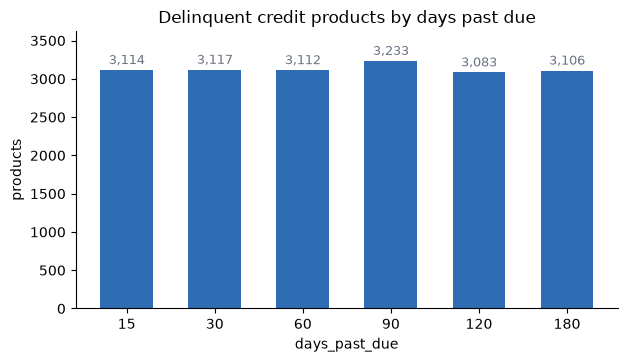

In [8]:
delinquent = credit[credit["is_delinquent"]]
delinquent_by_dpd = delinquent["days_past_due"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(delinquent_by_dpd.index.astype(int).astype(str), delinquent_by_dpd.values, color=BAR_COLOR, width=0.6)
for position, count in enumerate(delinquent_by_dpd.values):
    ax.text(position, count + 40, f"{count:,}", ha="center", va="bottom", fontsize=9, color=MUTED_COLOR)
ax.set_title("Delinquent credit products by days past due")
ax.set_xlabel("days_past_due")
ax.set_ylabel("products")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, delinquent_by_dpd.max() * 1.12)
plt.show()

## 5. Sizing the opportunity

**Currency caveat.** Balances are in COP, USD and ARS and the file has **no exchange rates**.
Summing across currencies would require inventing a rate, so every monetary figure below is
reported **per currency**.

**Balance caveat.** The file has `current_balance` only. There is no overdue/installment amount,
so "balance of delinquent products" is *total exposure* on those products, an upper bound on
what is actually past due, not the overdue amount itself.

In [9]:
def summarize_exposure(frame: pd.DataFrame) -> pd.DataFrame:
    """Summarizes products, customers and balance per currency.

    Exists so credit-book and delinquent-book figures are built the same way and can be compared.

    Args:
        frame: Credit products to summarize.

    Returns:
        pd.DataFrame: one row per currency with product count, customer count, total and median balance.
    """
    return frame.groupby("currency").agg(
        products=("product_id", "size"),
        customers=("customer_id", "nunique"),
        total_balance=("current_balance", "sum"),
        median_balance=("current_balance", "median"),
    )


credit_book = summarize_exposure(credit)
delinquent_book = summarize_exposure(delinquent)

headline = pd.Series(
    {
        "credit products with a days_past_due value": len(credit),
        "credit customers": credit["customer_id"].nunique(),
        "delinquent products (days_past_due > 0)": len(delinquent),
        "delinquent customers (>= 1 delinquent product)": delinquent["customer_id"].nunique(),
        "delinquent customers as % of credit customers":
            delinquent["customer_id"].nunique() / credit["customer_id"].nunique() * 100,
        "delinquent products as % of credit products": len(delinquent) / len(credit) * 100,
    },
    name="value",
)
display(headline.to_frame())
display(credit_book.add_prefix("credit_book_"))
display(delinquent_book.add_prefix("delinquent_"))
display((delinquent_book["total_balance"] / credit_book["total_balance"] * 100).to_frame("delinquent_share_of_balance_pct"))

,value
credit products with a days_past_due value,"125,350.00"
credit customers,"84,926.00"
delinquent products (days_past_due > 0),"18,765.00"
delinquent customers (>= 1 delinquent product),"17,650.00"
delinquent customers as % of credit customers,20.78
delinquent products as % of credit products,14.97


,credit_book_products,credit_book_customers,credit_book_total_balance,credit_book_median_balance
currency,,,,
ARS,22375,15733,"74,124,937,152.82","622,190.28"
COP,33780,23781,"1,294,937,696,429.96","7,143,379.95"
USD,69195,48617,"664,907,063.88","1,784.51"


,delinquent_products,delinquent_customers,delinquent_total_balance,delinquent_median_balance
currency,,,,
ARS,3342,3170,"11,401,471,219.03","616,557.18"
COP,5085,4826,"188,935,509,727.34","7,055,020.18"
USD,10338,9752,"101,981,317.59","1,778.12"


,delinquent_share_of_balance_pct
currency,
ARS,15.38
COP,14.59
USD,15.34


### Exposure by aging bucket (per currency)

Aging matters for the use case: collections effort is usually most productive on the early
buckets, and the late buckets are where money is most at risk.

In [10]:
by_bucket = (
    delinquent.groupby(["dpd_bucket", "currency"], observed=True)
    .agg(products=("product_id", "size"), balance=("current_balance", "sum"))
    .unstack("currency")
)
display(by_bucket["products"].assign(total=lambda t: t.sum(axis=1)))
display(by_bucket["balance"])

currency,ARS,COP,USD,total
dpd_bucket,,,,
1-30,1067,1685,3479,6231
31-60,546,815,1751,3112
61-90,612,899,1722,3233
91-120,562,865,1656,3083
121-180,555,821,1730,3106


currency,ARS,COP,USD
dpd_bucket,,,
1-30,"3,528,124,180.59","67,093,986,370.33","33,566,865.01"
31-60,"1,942,265,748.89","26,133,892,808.31","17,310,126.21"
61-90,"1,820,194,222.76","35,307,084,357.14","17,531,203.22"
91-120,"2,173,450,563.35","30,709,292,521.97","16,837,582.94"
121-180,"1,937,436,503.44","29,691,253,669.59","16,735,540.21"


### Status of delinquent products

Delinquent products that are `Closed` / `Blocked` / `Suspended` may not be actionable in the
same way as `Active` ones, so the addressable population is smaller than the headline.

In [11]:
status_view = (
    delinquent.groupby(["product_status", "currency"])
    .agg(products=("product_id", "size"), balance=("current_balance", "sum"))
    .unstack("currency")
)
display(status_view)

active_delinquent = delinquent[delinquent["product_status"] == "Active"]
display(summarize_exposure(active_delinquent).add_prefix("active_delinquent_"))
display(pd.Series({
    "delinquent customers with >= 1 Active delinquent product": active_delinquent["customer_id"].nunique(),
    "delinquent products with balance == 0": (delinquent["current_balance"] == 0).sum(),
    "customers with >= 2 delinquent products": (delinquent.groupby("customer_id").size() >= 2).sum(),
}, name="value").to_frame())

products                      balance                                 
currency            ARS   COP   USD              ARS                COP           USD
product_status                                                                       
Active             2823  4313  8753 9,631,357,002.28 160,467,383,369.10 86,313,316.96
Blocked             156   281   525   665,781,259.54  10,164,505,246.83  6,045,683.28
Closed              285   394   835   866,723,478.50  15,461,230,320.71  7,428,105.56
Suspended            78    97   225   237,609,478.71   2,842,390,790.70  2,194,211.79

,active_delinquent_products,active_delinquent_customers,active_delinquent_total_balance,active_delinquent_median_balance
currency,,,,
ARS,2823,2695,"9,631,357,002.28","613,653.46"
COP,4313,4121,"160,467,383,369.10","7,050,277.12"
USD,8753,8341,"86,313,316.96","1,778.52"


,value
delinquent customers with >= 1 Active delinquent product,15089
delinquent products with balance == 0,443
customers with >= 2 delinquent products,1069


### Value of a small improvement (arithmetic only, not a forecast)

We have no payment or recovery data, so we cannot estimate how much faster prioritised
collections would bring cash in. What we *can* do is show what each 1% of delinquent exposure is
worth. Any real business case must plug its own recovery/speed-up assumption into this base.

In [12]:
active_balance = active_delinquent.groupby("currency")["current_balance"].sum()
display(pd.DataFrame({
    "active_delinquent_balance": active_balance,
    "1%_of_it": active_balance * 0.01,
    "5%_of_it": active_balance * 0.05,
}))

,active_delinquent_balance,1%_of_it,5%_of_it
currency,,,
ARS,"9,631,357,002.28","96,313,570.02","481,567,850.11"
COP,"160,467,383,369.10","1,604,673,833.69","8,023,369,168.46"
USD,"86,313,316.96","863,133.17","4,315,665.85"


## 6. Can this data support a time-to-payment model?

Two independent questions: is there a **target**, and is there **signal** in the available
features? Signal is checked descriptively only: if delinquency depends on a feature, the
delinquency rate should differ between that feature's segments.

### 6a. Target availability

In [13]:
target_readiness = pd.DataFrame(
    [
        ("Payment date per delinquent product", "absent"),
        ("Payment amount / overdue amount", "absent (only total current_balance)"),
        ("History / multiple snapshots per product", "absent (1 row per product_id)"),
        ("Collections contact / action log", "absent"),
        ("days_past_due as a continuous measure", "present but only 7 distinct values"),
        ("Exchange rates for cross-currency totals", "absent"),
    ],
    columns=["needed", "in products.csv"],
)
display(target_readiness)

,needed,in products.csv
0,Payment date per delinquent product,absent
1,Payment amount / overdue amount,absent (only total current_balance)
2,History / multiple snapshots per product,absent (1 row per product_id)
3,Collections contact / action log,absent
4,days_past_due as a continuous measure,present but only 7 distinct values
5,Exchange rates for cross-currency totals,absent


`days_past_due` is **how long a product has been late so far**, not how long until it is paid.
A delinquent row with `days_past_due = 60` tells us nothing about whether or when it will be
paid. Time-to-payment is a duration that is observed only after payment (or censored if it never
happens), and nothing in this file records either event.

### 6b. Signal in the features (descriptive)

In [14]:
def delinquency_rate_by_segment(frame: pd.DataFrame, segment: pd.Series, label: str) -> pd.DataFrame:
    """Computes the delinquency rate for each segment of one feature.

    Exists so all features are compared on identical terms against the overall rate.

    Args:
        frame: Credit products with the is_delinquent flag.
        segment: Segment assignment aligned to frame's index.
        label: Feature name shown in the output.

    Returns:
        pd.DataFrame: one row per segment with feature, segment, products and delinquency rate (%).
    """
    grouped = frame["is_delinquent"].groupby(segment, observed=True).agg(["mean", "size"])
    return pd.DataFrame({
        "feature": label,
        "segment": grouped.index.astype(str),
        "products": grouped["size"].to_numpy(),
        "delinquent_rate_pct": grouped["mean"].to_numpy() * 100,
    })


utilization = credit["current_balance"] / credit["credit_limit"]
segments = {
    "product_type": credit["product_type"],
    "currency": credit["currency"],
    "product_status": credit["product_status"],
    "opening_channel": credit["opening_channel"],
    "has_linked_app": credit["has_linked_app"],
    "opening_year": credit["opening_date"].dt.year,
    "interest_rate (quintile)": pd.qcut(credit["interest_rate"], 5, duplicates="drop"),
    "balance (quintile within currency)": credit.groupby("currency")["current_balance"].transform(
        lambda s: pd.qcut(s, 5, labels=False) + 1
    ),
    "utilization (balance / limit)": pd.cut(utilization, [0, 0.25, 0.5, 0.75, 1, float("inf")]),
}
segment_rates = pd.concat(
    [delinquency_rate_by_segment(credit, values, name) for name, values in segments.items()],
    ignore_index=True,
)
overall_rate = credit["is_delinquent"].mean() * 100
display(segment_rates.groupby("feature")["delinquent_rate_pct"].agg(["min", "max"]).assign(spread=lambda t: t["max"] - t["min"]))
overall_rate

,min,max,spread
feature,,,
balance (quintile within currency),14.67,15.26,0.59
currency,14.94,15.05,0.12
has_linked_app,14.92,15.02,0.10
interest_rate (quintile),14.75,15.37,0.61
opening_channel,14.10,15.09,0.99
opening_year,14.63,15.31,0.68
product_status,14.91,15.96,1.05
product_type,14.94,15.22,0.27
utilization (balance / limit),14.66,15.63,0.97


np.float64(14.970083765456721)

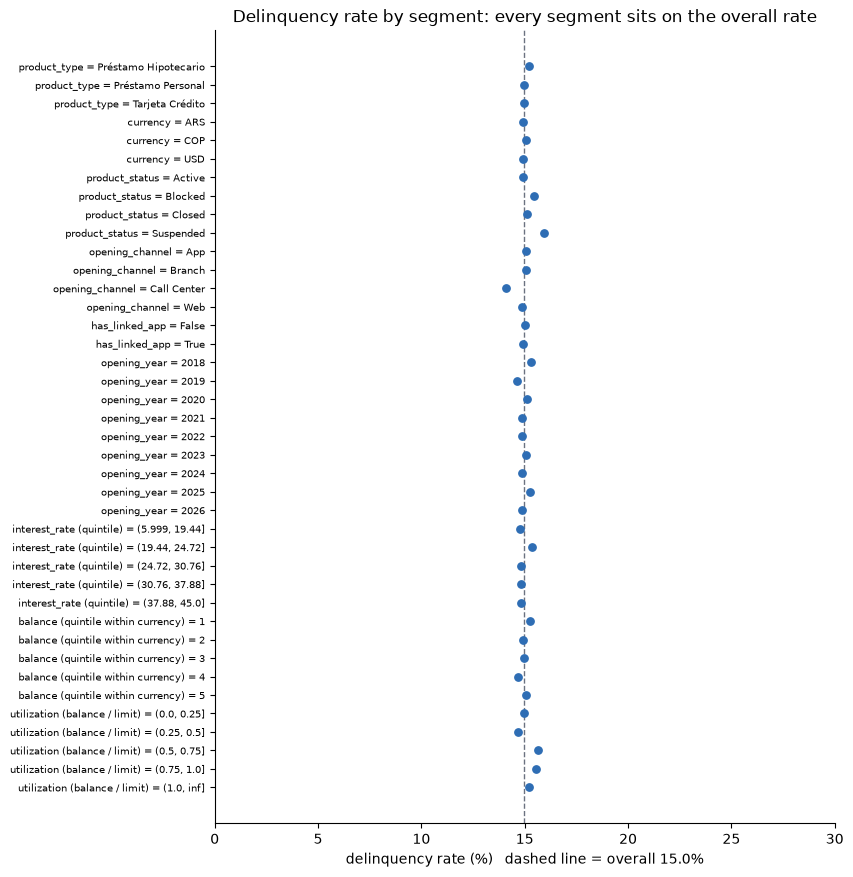

In [15]:
plot_frame = segment_rates.iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 0.22 * len(plot_frame) + 1.5))
ax.axvline(overall_rate, color=MUTED_COLOR, linewidth=1, linestyle="--")
ax.scatter(plot_frame["delinquent_rate_pct"], plot_frame.index, s=28, color=BAR_COLOR, zorder=3)
ax.set_yticks(plot_frame.index)
ax.set_yticklabels(plot_frame["feature"] + " = " + plot_frame["segment"], fontsize=7)
ax.set_xlim(0, 30)
ax.set_xlabel(f"delinquency rate (%)   dashed line = overall {overall_rate:.1f}%")
ax.set_title("Delinquency rate by segment: every segment sits on the overall rate")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

If any feature carried signal, its segments would spread away from the dashed line. They do not:
across all nine features the segments stay within about a percentage point of the overall rate.
Since delinquency itself is not related to these features, it is hard to expect that *how long*
a delinquency lasts would be.

In [16]:
rank_correlation = pd.Series({
    column: credit["days_past_due"].rank().corr(credit[column].rank())
    for column in ["current_balance", "credit_limit", "interest_rate"]
}, name="spearman_with_days_past_due")
display(rank_correlation.to_frame())

customer_profile = credit.groupby("customer_id")["is_delinquent"].agg(products="size", delinquent="sum")
multi = customer_profile[customer_profile["products"] >= 2]
overall_probability = credit["is_delinquent"].mean()
display(pd.Series({
    "customers with >= 2 credit products": len(multi),
    "share with >= 1 delinquent product (observed)": (multi["delinquent"] > 0).mean() * 100,
    "share expected if products were independent": (1 - (1 - overall_probability) ** multi["products"]).mean() * 100,
    "share with ALL products delinquent (observed)": (multi["delinquent"] == multi["products"]).mean() * 100,
    "share expected if products were independent (all delinquent)": (overall_probability ** multi["products"]).mean() * 100,
}, name="percent").to_frame())

,spearman_with_days_past_due
current_balance,-0.00
credit_limit,0.00
interest_rate,-0.00


,percent
customers with >= 2 credit products,"30,630.00"
share with >= 1 delinquent product (observed),31.40
share expected if products were independent,31.05
share with ALL products delinquent (observed),1.84
share expected if products were independent (all delinquent),1.73


Two more descriptive checks. Rank correlations between `days_past_due` and balance, limit and
interest rate are essentially zero. And delinquency is barely more concentrated within customers
than chance would give: a customer with one delinquent product is only marginally more likely to
have another. Real portfolios normally show clear customer-level clustering.

**Consistency checks that also point to non-real data:**

In [17]:
age_days = (REFERENCE_DATE - credit["opening_date"]).dt.days
display(pd.Series({
    "delinquent with days_past_due greater than the product's age": (credit["days_past_due"] > age_days).sum(),
    "delinquent with balance 0": (delinquent["current_balance"] == 0).sum(),
    "credit products with balance above credit_limit": (credit["current_balance"] > credit["credit_limit"]).sum(),
    "Closed credit products still delinquent with balance > 0":
        ((credit["product_status"] == "Closed") & credit["is_delinquent"] & (credit["current_balance"] > 0)).sum(),
}, name="count").to_frame())

,count
delinquent with days_past_due greater than the product's age,526
delinquent with balance 0,443
credit products with balance above credit_limit,7122
Closed credit products still delinquent with balance > 0,1475


## 7. Conclusions

**Is there an opportunity? In size, yes.**

- 125,350 credit products (cards, personal loans, mortgages) across 84,926 customers have a
  `days_past_due` value. **18,765 products (15.0%) held by 17,650 customers (20.8% of credit
  customers) are delinquent.**
- Exposure on those delinquent products (total balance, not overdue amount): roughly
  **COP 188.9 bn, ARS 11.4 bn and USD 102.0 M**. There are no FX rates in the file, so these
  cannot be honestly added into one figure.
- Only part of that is directly actionable: 15,089 delinquent customers have at least one `Active`
  delinquent product (see the `Active`-only table in section 5). Each 1%
  of active delinquent balance is shown per currency there, as the base for any future
  business case.
- Each of the seven days_past_due values holds ~3,100 products (the 1-30 bucket looks twice as large
  only because it spans two values, 15 and 30), so there is no dominant "early and easy" segment
  in this file that a prioritisation rule would obviously exploit.

**Can a time-to-payment model be built from this file? No, and I would not proceed on it.**

1. **There is no target.** No payment dates, amounts, due dates, history or collection actions;
   one row per product at one point in time. `days_past_due` measures how late a product is now,
   not when it gets paid.
2. **No visible signal.** Delinquency is ~15% in every segment of every feature, uncorrelated
   with balance, limit and rate, and almost not clustered by customer. Even a target with
   payment dates would have nothing here to predict from, on this evidence.
3. **The data looks synthetic or heavily coded.** `days_past_due` takes exactly seven values,
   the 15% rate is flat everywhere, and there are internal inconsistencies (timestamps out of
   order or in the future, `days_past_due` larger than product age, delinquent closed products
   carrying balances). I cannot prove it is synthetic, but real portfolio data rarely looks like
   this, so results from it should not be trusted to transfer to production.

**What would change the answer** (data to request before revisiting the modelling question):

- A payments/collections ledger: payment date and amount per obligation, due date and overdue
  amount, ideally at installment level, so time-to-payment (and censoring for unpaid) can be defined.
- Repeated snapshots (e.g. monthly) so roll rates and cure rates can be measured.
- A log of collection contacts and outcomes, to separate customers who pay by themselves from
  those who pay because they were contacted (needed to make the prioritisation causally useful).
- Customer-level attributes (income, behaviour, contact channel) and FX rates for a single-currency
  valuation.

**Recommended next step:** get the payment ledger and re-run this EDA on it, starting with the
share of delinquent obligations that actually get paid, the distribution of observed time to
payment, and whether it differs by segment. That is the cheapest test of the hypothesis before
any modelling.